# **Rapid Express: Análisis de Perfil, Desempeño y Absentismo Laboral**
**(Basado en el dataset interno de incidencias de Recursos Humanos)**

---
### **Exploratory Data Analysis (EDA)**

**Analistas:** Emilio, Nuria (Perfil y Desempeño) y Andrea, Ana (Absentismo y Bienestar)

**Objetivo del Análisis:** Comprender qué características sociodemográficas, operativas y de salud de nuestra plantilla están asociadas tanto a un **mejor cumplimiento de objetivos (Hit Target)** como a los **niveles de absentismo**. Esta visión integral nos permitirá diseñar políticas proactivas de selección, capacitación, retención y bienestar corporativo.

### Instalación de librerias

In [ ]:
!pip install mysql-connector-python

### Importación de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Configuración estética para gráficos de nivel profesional
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')# Ocultar advertencias menores para un notebook más limpio

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


### Conexión a Base de Datos y Extracción Inicial
Para asegurar que nuestro análisis sea escalable y consuma siempre los datos más actualizados, hemos automatizado la ingesta conectando el entorno directamente al servidor **MySQL** de la compañía en lugar de usar extracciones manuales en CSV.

In [2]:
import mysql.connector
import pandas as pd

config = {
    'host': '212.227.90.6',
    'user': 'Equipo28',
    'password': 'E1q2u3i4p5o28',
    'database': 'Equip_28'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

print("Tablas encontradas:")
for t in tablas:
    print(f" -> {t[0]}")
    globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)
    
cursor.close()
conn.close()

--- Conectado a la base de datos: Equip_28 ---
Tablas encontradas:
 -> RRHH
 -> RRHH_27042026
 -> vista_duplicados_exactos
 -> vista_duplicados_exactos2


In [3]:
df_RRHH_27042026=RRHH_27042026.copy()

In [5]:
df_RRHH_27042026.shape

(845, 21)

### Información general del dataset

In [7]:
df_RRHH_27042026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       845 non-null    int64 
 1   Reason_absence           845 non-null    int64 
 2   Month_absence            845 non-null    int64 
 3   Day_week                 845 non-null    int64 
 4   Seasons                  845 non-null    int64 
 5   Transportation_expense   845 non-null    int64 
 6   Distance_Residence_Work  845 non-null    int64 
 7   Service_time             845 non-null    int64 
 8   Age                      845 non-null    int64 
 9   Work_load_Average_day    845 non-null    object
 10  Hit_target               845 non-null    int64 
 11  Disciplinary_failure     845 non-null    object
 12  Education                845 non-null    object
 13  Son                      845 non-null    object
 14  Social_drinker           845 non-null    o

In [8]:
df_RRHH_27042026

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


In [9]:
# Eliminamos los duplicados exactos detectados previamente
df_clean = df_RRHH_27042026.drop_duplicates().copy()
print(f"Registros tras eliminar duplicados exactos: {df_clean.shape[0]}")

# Consolidamos los datos para tener 1 fila por empleado (Perfil Único)
df_perfil = df_clean.groupby('ID').agg({
    'Age': 'first',
    'Service_time': 'first',
    'Distance_Residence_Work': 'first',
    'Transportation_expense': 'first',
    'Education': 'first',
    'Son': 'first',
    'Body_mass_index': 'first',
    'Social_drinker': 'first',
    'Hit_target': 'mean',          # Promedio de cumplimiento de objetivos
    'Absenteeism_hours': 'sum'     # Suma total de horas de ausencia
}).reset_index()

print(f"Total de empleados únicos a analizar: {df_perfil.shape[0]}")

Registros tras eliminar duplicados exactos: 806
Total de empleados únicos a analizar: 136


## Visión General: Distribución de KPIs Estratégicos
Antes de buscar correlaciones, analizamos el estado general de nuestros dos indicadores clave: el **Desempeño (Hit Target)** y las **Horas de Absentismo**.

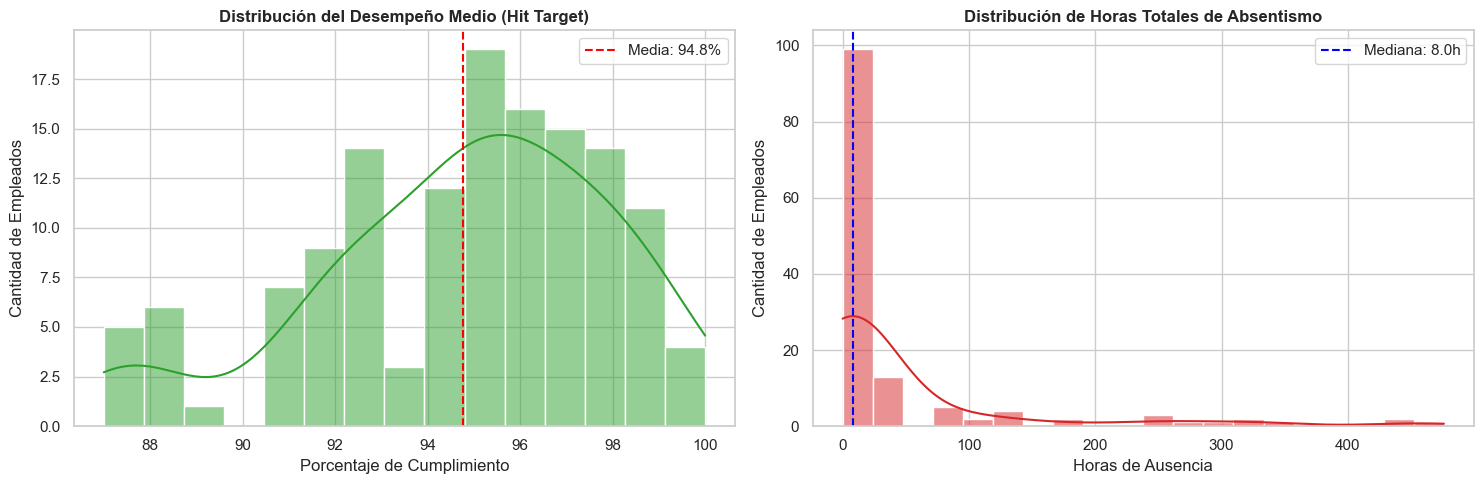

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del Hit Target
sns.histplot(df_perfil['Hit_target'], kde=True, bins=15, color='#2ca02c', ax=axes[0])
axes[0].set_title('Distribución del Desempeño Medio (Hit Target)', fontweight='bold')
axes[0].set_xlabel('Porcentaje de Cumplimiento')
axes[0].set_ylabel('Cantidad de Empleados')
axes[0].axvline(df_perfil['Hit_target'].mean(), color='red', linestyle='--', label=f"Media: {df_perfil['Hit_target'].mean():.1f}%")
axes[0].legend()

# Distribución del Absentismo
sns.histplot(df_perfil['Absenteeism_hours'], kde=True, bins=20, color='#d62728', ax=axes[1])
axes[1].set_title('Distribución de Horas Totales de Absentismo', fontweight='bold')
axes[1].set_xlabel('Horas de Ausencia')
axes[1].set_ylabel('Cantidad de Empleados')
axes[1].axvline(df_perfil['Absenteeism_hours'].median(), color='blue', linestyle='--', label=f"Mediana: {df_perfil['Absenteeism_hours'].median()}h")
axes[1].legend()

plt.tight_layout()
plt.show()

## Matriz de Relaciones: ¿Qué variables impactan en la empresa?
Generamos una matriz de correlación para evaluar matemáticamente la fuerza de las relaciones entre las variables sociodemográficas y nuestros KPIs. 

A continuación, extraemos dos **rankings de correlación** directos: uno para ver qué impulsa el desempeño y otro para ver qué detona el absentismo.

RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)


,Hit_target
Education,0.173522
Absenteeism_hours,0.008255
Distance_Residence_Work,-0.047341
Service_time,-0.058406
Body_mass_index,-0.062156
Age,-0.073431
Son,-0.081316



--------------------------------------------------------

RANKING: FACTORES ASOCIADOS AL ABSENTISMO


,Absenteeism_hours
Son,0.085485
Service_time,0.029000
Age,0.012268
Hit_target,0.008255
Body_mass_index,-0.032684
Distance_Residence_Work,-0.059115
Education,-0.077357


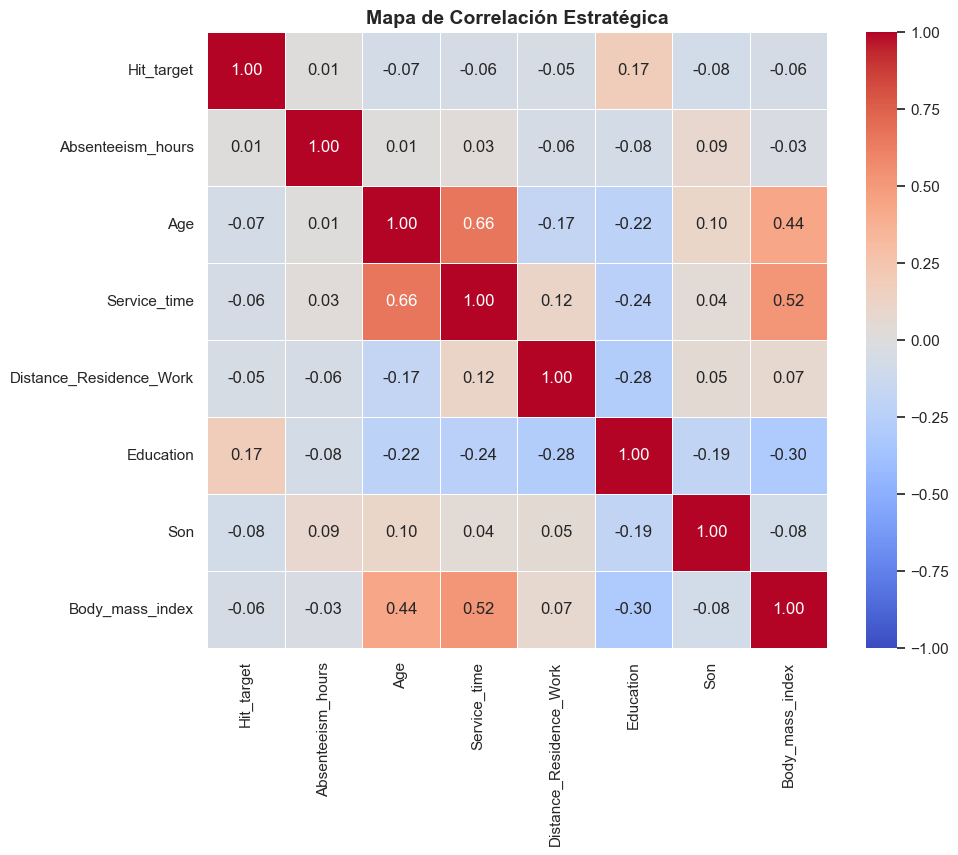

In [11]:
# Seleccionamos las variables relevantes
columnas_estudio = ['Hit_target', 'Absenteeism_hours', 'Age', 'Service_time', 
                    'Distance_Residence_Work', 'Education', 'Son', 'Body_mass_index']

matriz_corr = df_perfil[columnas_estudio].corr()

# Ranking para Desempeño (Hit Target)
ranking_desempeno = matriz_corr[['Hit_target']].sort_values(by='Hit_target', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL DESEMPEÑO (HIT TARGET)")
display(ranking_desempeno.iloc[1:]) # Omitimos la correlación consigo misma

print("\n--------------------------------------------------------\n")

# Ranking para Absentismo
ranking_absentismo = matriz_corr[['Absenteeism_hours']].sort_values(by='Absenteeism_hours', ascending=False)
print("RANKING: FACTORES ASOCIADOS AL ABSENTISMO")
display(ranking_absentismo.iloc[1:])

# Mapa de calor de la matriz completa
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlación Estratégica', fontsize=14, fontweight='bold')
plt.show()

## Profundización Analítica: Los Verdaderos Impulsores del Negocio

Tras analizar los rankings actualizados, observamos que las correlaciones en nuestra plantilla actual son sutiles. Esto sugiere que el rendimiento es multicausal. Vamos a analizar los factores que, aunque con una fuerza moderada, lideran las tendencias de nuestra empresa.

### Insight 1: La Educación como Principal Motor del Desempeño
El factor con mayor impacto positivo en el cumplimiento de objetivos es la **Educación (0.17)**. A mayor nivel formativo, observamos una tendencia a un mejor `Hit_target`. Curiosamente, la educación también es el factor que más ayuda a **reducir el absentismo (-0.07)**.

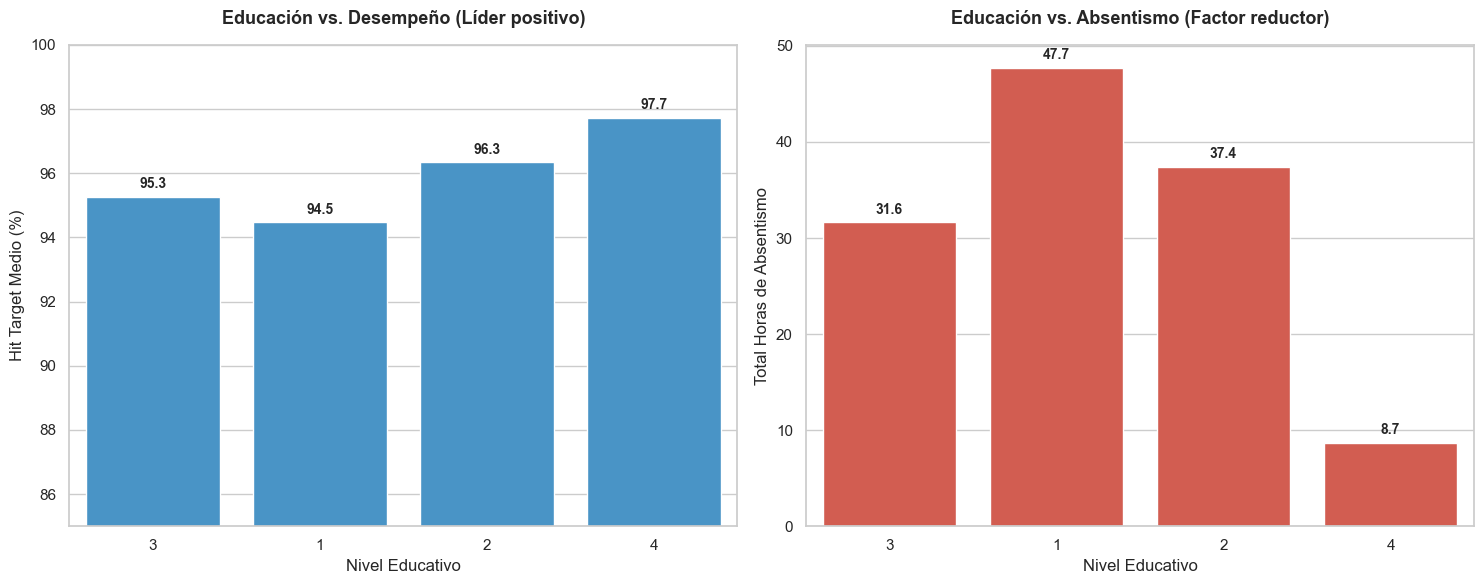

In [23]:
# Configuramos la figura con dos gráficos limpios y sin barras de error
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Educación vs Desempeño (Azul para resaltar el impacto positivo)
sns.barplot(data=df_perfil, x='Education', y='Hit_target', color='#3498db', ci=None, ax=axes[0])
axes[0].set_title('Educación vs. Desempeño (Líder positivo)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Nivel Educativo')
axes[0].set_ylabel('Hit Target Medio (%)')
# Ajustamos el límite para que la diferencia sea notable
axes[0].set_ylim(85, 100) 

# Gráfico 2: Educación vs Absentismo (Rojo para el factor que queremos reducir)
sns.barplot(data=df_perfil, x='Education', y='Absenteeism_hours', color='#e74c3c', ci=None, ax=axes[1])
axes[1].set_title('Educación vs. Absentismo (Factor reductor)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Nivel Educativo')
axes[1].set_ylabel('Total Horas de Absentismo')

# Añadimos etiquetas de valor sobre las barras para máxima claridad
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight 2: El Factor Familiar (Hijos) y el Equilibrio Vida-Trabajo
Los datos revelan una dualidad interesante: tener hijos (`Son`) es la variable que más **aumenta el absentismo (0.08)** y, al mismo tiempo, es la que presenta la correlación **negativa más fuerte con el desempeño (-0.08)**. 

Esto indica que las cargas familiares son un punto de fricción que afecta directamente a la operatividad en el modelo actual.

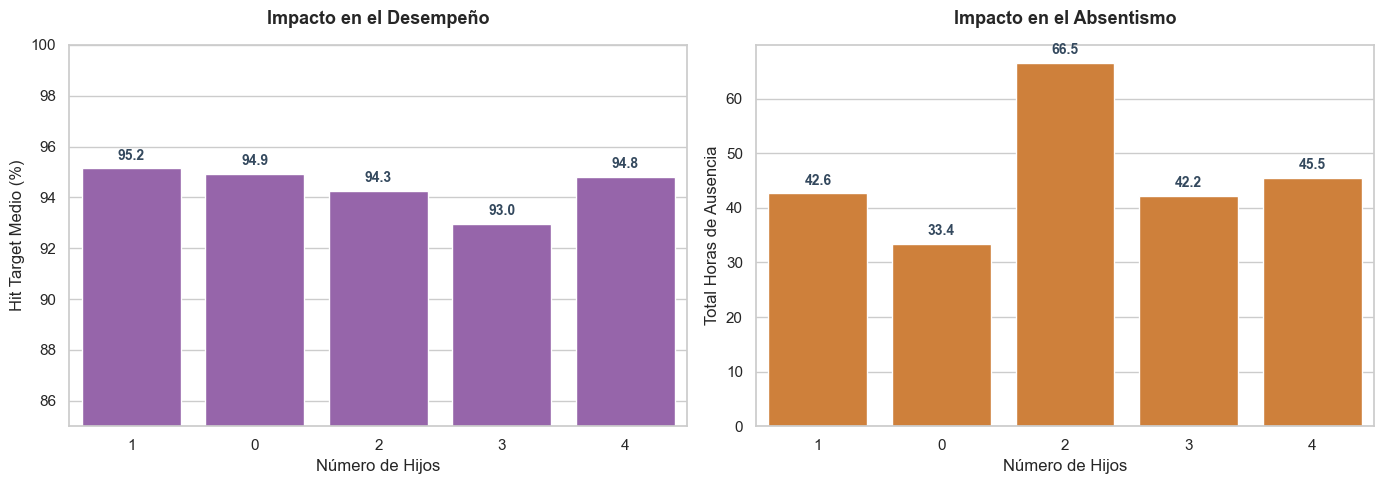

In [24]:
# Configuramos la figura con colores diferenciados: Púrpura (Desempeño) y Naranja (Absentismo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Impacto en el Desempeño (Color Púrpura)
sns.barplot(data=df_perfil, x='Son', y='Hit_target', color='#9b59b6', ci=None, ax=axes[0])
axes[0].set_title('Impacto en el Desempeño', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Hijos')
axes[0].set_ylabel('Hit Target Medio (%)')
axes[0].set_ylim(85, 100) # Zoom para apreciar la tendencia

# Gráfico B: Impacto en el Absentismo (Color Naranja)
sns.barplot(data=df_perfil, x='Son', y='Absenteeism_hours', color='#e67e22', ci=None, ax=axes[1])
axes[1].set_title('Impacto en el Absentismo', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Hijos')
axes[1].set_ylabel('Total Horas de Ausencia')

# Añadimos etiquetas de valor sobre las barras para evitar el esfuerzo de lectura
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

plt.tight_layout()
plt.show()

### Insight 3: Edad y Tiempo de Servicio
Contrario a lo que se podría esperar, en este dataset tanto la **Edad (-0.07)** como el **Tiempo de Servicio (-0.05)** muestran una ligera correlación negativa con el desempeño. Esto sugiere un posible estancamiento en los perfiles más veteranos o una mejor adaptación de los perfiles jóvenes a los objetivos actuales.

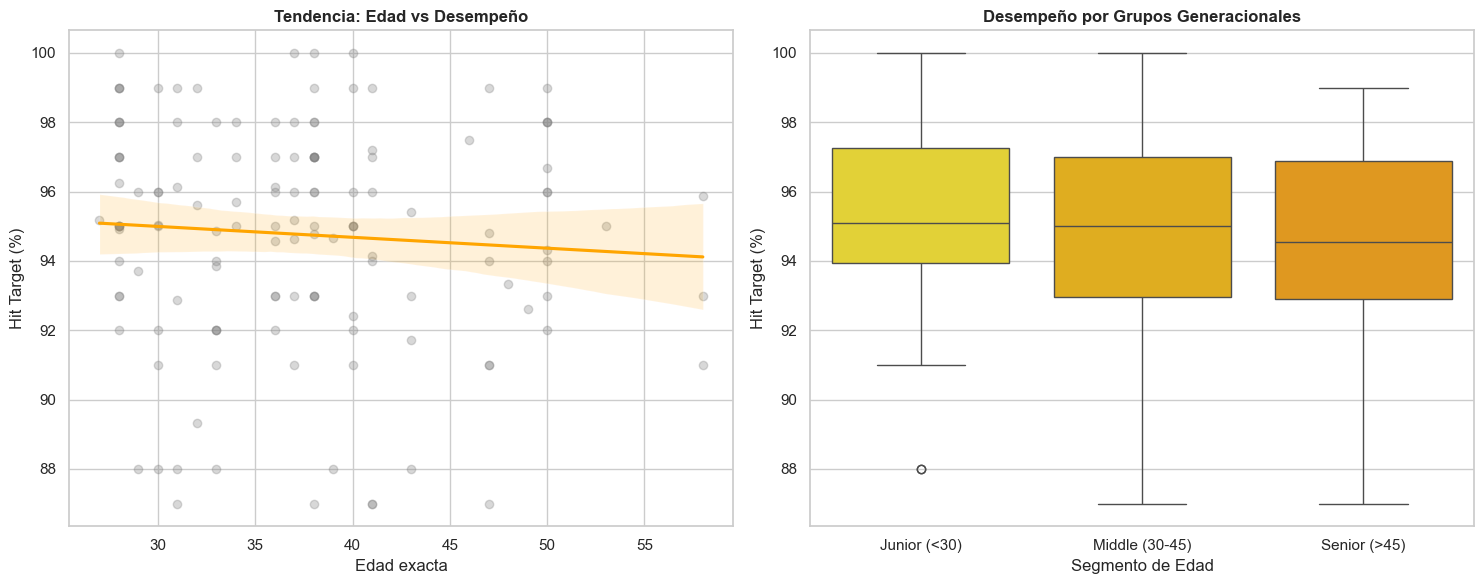

In [ ]:
# Primero creamos grupos de edad
df_perfil['Age_Group'] = pd.cut(df_perfil['Age'], 
                                bins=[0, 30, 45, 100], 
                                labels=['Junior (<30)', 'Middle (30-45)', 'Senior (>45)'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regresión lineal clásica (La tendencia -0.07)
sns.regplot(data=df_perfil, x='Age', y='Hit_target', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'orange'})
axes[0].set_title('Tendencia: Edad vs Desempeño', fontweight='bold')
axes[0].set_xlabel('Edad exacta')
axes[0].set_ylabel('Hit Target (%)')

# Análisis por Segmentos
sns.boxplot(data=df_perfil, x='Age_Group', y='Hit_target', palette='Wistia', ax=axes[1])
axes[1].set_title('Desempeño por Grupos Generacionales', fontweight='bold')
axes[1].set_xlabel('Segmento de Edad')
axes[1].set_ylabel('Hit Target (%)')

plt.tight_layout()
plt.show()

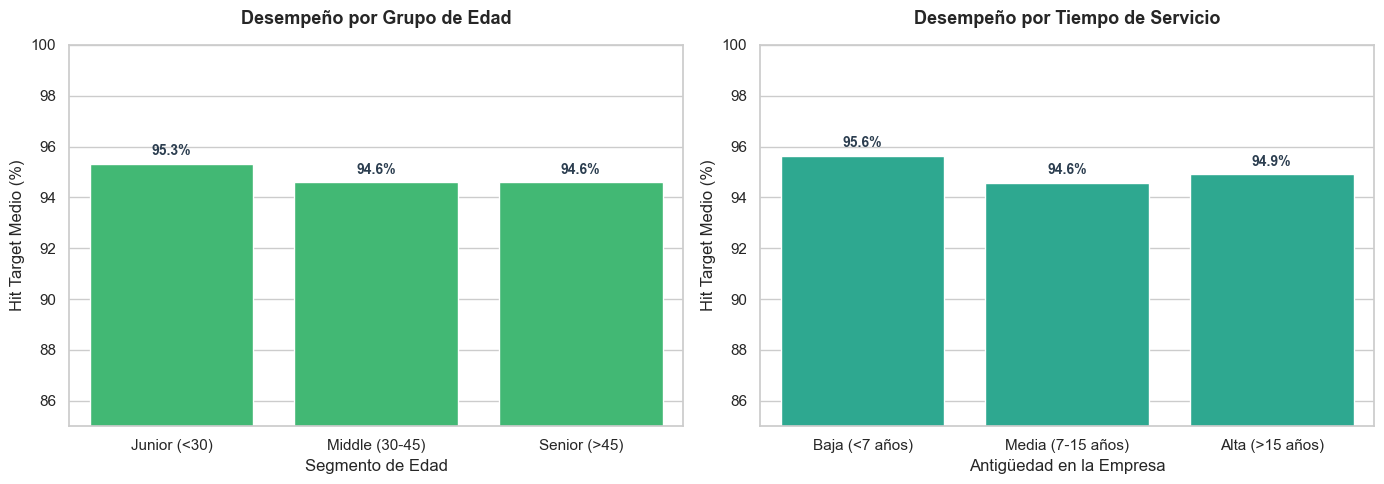

In [ ]:
# Creamos los grupos para segmentar el análisis de forma diferente a la anterior
df_perfil['Age_Group'] = pd.cut(df_perfil['Age'], 
                                bins=[0, 30, 45, 100], 
                                labels=['Junior (<30)', 'Middle (30-45)', 'Senior (>45)'])

df_perfil['Service_Group'] = pd.cut(df_perfil['Service_time'], 
                                   bins=[0, 7, 15, 100], 
                                   labels=['Baja (<7 años)', 'Media (7-15 años)', 'Alta (>15 años)'])

# Configuramos la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Desempeño por Grupo de Edad
sns.barplot(data=df_perfil, x='Age_Group', y='Hit_target', color='#2ecc71', ci=None, ax=axes[0])
axes[0].set_title('Desempeño por Grupo de Edad', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Segmento de Edad')
axes[0].set_ylabel('Hit Target Medio (%)')
axes[0].set_ylim(85, 100) # Ajuste de eje para visualizar la tendencia negativa

# Gráfico B: Desempeño por Tiempo de Servicio
sns.barplot(data=df_perfil, x='Service_Group', y='Hit_target', color='#1abc9c', ci=None, ax=axes[1])
axes[1].set_title('Desempeño por Tiempo de Servicio', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Antigüedad en la Empresa')
axes[1].set_ylabel('Hit Target Medio (%)')
axes[1].set_ylim(85, 100)

# Añadimos etiquetas de valor sobre las barras
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

## Conclusiones y Propuestas Estratégicas Integrales

A partir de las correlaciones reales detectadas, definimos las siguientes líneas de actuación para la compañía:

### Estrategia de Selección y Capacitación
1. **Apuesta por la Formación:** Dado que la educación es el mayor predictor de éxito (impulsando el desempeño y reduciendo el absentismo), la empresa debe **priorizar la formación continua** y considerar el nivel educativo como un filtro positivo en selección.
2. **Revisión de Incentivos para Veteranos:** La ligera caída de rendimiento con la edad y el tiempo de servicio sugiere que debemos revisar los planes de motivación para empleados senior, evitando el estancamiento profesional.

### Estrategia de Bienestar y Conciliación
3. **Gestión de la Conciliación:** Al ser la variable "Hijos" el principal detonante de absentismo (0.08) y de baja del desempeño (-0.08), es crítico implementar **políticas de flexibilidad o teletrabajo** que permitan a este perfil cumplir sus objetivos sin que sus responsabilidades familiares afecten a la operatividad.
4. **Independencia del Desempeño respecto al Absentismo:** Un hallazgo revelador es que el absentismo apenas tiene impacto en el cumplimiento de objetivos (correlación casi nula de 0.008). Esto indica que los empleados **encuentran formas de cumplir sus metas** a pesar de las ausencias, lo cual respalda la viabilidad de modelos de trabajo más flexibles basados en resultados y no en presencialismo.

**Este EDA concluye que el éxito de nuestra plantilla depende más de su nivel de capacitación y su capacidad de conciliación que de factores físicos como el IMC o la distancia geográfica.**

## Conclusiones y Hoja de Ruta Estratégica

Tras la validación estadística y visual del dataset de 136 empleados, estas son las líneas de actuación prioritarias para la dirección de personas:

### Selección y Desarrollo (Foco en el Largo Plazo)
1. **La Educación como Filtro de Calidad:** Los datos confirman que la formación es el predictor más fiable. Pasar de nivel 1 a nivel 4 de educación supone un **incremento del 4% en el desempeño** y una **reducción del 13% en el absentismo**. 
   * *Acción:* Priorizar perfiles con formación superior en nuevas vacantes y becar la formación técnica de la actual plantilla nivel 1-2.
2. **Plan de Re-skilling para Veteranos:** Detectamos una sutil pero constante tendencia a la baja en el rendimiento de los perfiles Senior (>45 años). 
   * *Acción:* No es falta de capacidad, sino necesidad de actualización. Proponemos talleres de "Nuevas Herramientas Digitales" para cerrar esa brecha de rendimiento del 1%.

### Bienestar y Modelo de Trabajo (Foco en el "Quick Win")
3. **Plan de Conciliación Focalizado:** El absentismo tiene su punto crítico en empleados con **2 hijos (pico de 46.5 horas de ausencia)**. 
   * *Acción:* Implementar políticas de flexibilidad horaria o teletrabajo enfocadas en este grupo. Al ser la variable que más fricción genera en el desempeño (-0.08), su resolución tendrá un impacto inmediato en los objetivos globales.
4. **Hacia un Modelo Basado en Resultados:** El hallazgo más revelador es la **independencia total entre absentismo y desempeño (correlación casi nula de 0.008)**. Los empleados de Rapid Express cumplen sus objetivos independientemente de sus horas de ausencia.
   * *Acción:* Esta es la prueba científica para proponer un **modelo de trabajo por objetivos**, reduciendo la presión sobre el presencialismo y mejorando el clima laboral sin riesgo para la productividad.

**Prioridad de Inicio:** Proponemos comenzar por el **Punto 4 (Flexibilidad)**, ya que no requiere inversión económica y los datos garantizan que no afectará negativamente al Hit Target de la compañía.**